Task A2: Customer Churn Prediction
Author: Jianbin Hu Date: March 12, 2026 Module: IOM103--AI in Business

Before formally starting to build the model, we first confirm the application scenario and task objectives of this project.
We need the team to understand customer behavior and the attributes that lead to customer churn risk. We are required to use supervised learning models (logistic regression, classification tree, and random forest) for customer churn prediction. Creating a churn prediction model involves using historical customer data to predict the likelihood that current customers will leave or continue using a specific service or product.
Under the premise of these task requirements, our idea for building this customer churn prediction model is as follows:
First, import all required libraries. In this study, we specifically need to use three supervised learning models (logistic regression, classification tree, and random forest), and compare the training performance of the three models based on the AUROC metric to select the best-performing model for the final result output. Therefore, we import all libraries required for the three models, ROC and AUC for model construction.
Next, we import the dataset and clean invalid data to avoid unnecessary impacts on model training and testing.
After the dataset is fully processed, we can start the construction, training and optimization of the models.
In this key step, our approach is: build the three supervised learning models in a modular way, conduct data analysis with an 8:2 train/test split, and compare their performance respectively based on the AUROC metric, so as to select the best-performing model for the final result analysis. However, the default constructed models are generic, and each model may have unique advantages for this project. Therefore, after the first metric comparison, we can tune the parameters of all three models, and then conduct a more rigorous analysis to identify the model with the best performance based on the AUROC metric in this study. Through two rounds of model comparison, we believe the selected model is the most suitable for predicting actual customer churn.
Finally, using the optimal model selected through the above construction and comparison, after cross-validating the AUC error between the training set and the test set, we use the test set data to output the final customer churn prediction results.

1. Import required libraries

In [93]:
import pandas as pd               
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt  #Plotting (ROC curve, Feature importance plot)
from sklearn.model_selection import train_test_split, GridSearchCV  # Data Splitting and Hyperparameter Tuning
from sklearn.preprocessing import StandardScaler      
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier       # Classification Tree Model
from sklearn.ensemble import RandomForestClassifier   # Random Forest Model
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report  # Evaluation metrics
import matplotlib.pyplot as plt    # Plotting (for ROC curve)

import warnings
warnings.filterwarnings('ignore')

2 Loading Dataset

In [94]:
# Read CSV File
df = pd.read_csv('Customer-Churn_Task A2.csv')
print("Original Dataset Shape:", df.shape)   # Output (number of rows, number of columns)
print("Preview the first 5 rows of data:\n", df.head())

Original Dataset Shape: (7043, 21)
Preview the first 5 rows of data:
    customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...              

3. Data Cleaning and Preprocessing

In [95]:
# 3.1 Handle missing values in the TotalCharges column
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("TotalCharges Number of missing values:", df['TotalCharges'].isnull().sum())

df = df.dropna(subset=['TotalCharges'])

df = df.drop('customerID', axis=1)  # 3.2 Remove the unique identifier column customerID, it does not affect prediction

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})  # 3.3 Convert target variable Churn to numeric: Yes -> 1, No -> 0

cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical features to be encoded:", cat_cols)
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)  
# 3.4 Handle categorical features: One-hot encode all object type columns, drop_first=True to avoid multicollinearity

print("Dataset shape after one-hot encoding:", df_encoded.shape)
df_encoded.head()

TotalCharges Number of missing values: 11
Categorical features to be encoded: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Dataset shape after one-hot encoding: (7032, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


4. Split features and target variable

In [96]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

5. Split training set and test set

In [97]:
# Split the dataset into 80% training set and 20% test set. stratify=y ensures the churn ratio remains consistent with the original data distribution.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training set size: {X_train.shape[0]}, Test set size: {X_test.shape[0]}")
print(f"Training set churn ratio: {y_train.mean():.2%}, Test set churn ratio: {y_test.mean():.2%}")

Training set size: 5625, Test set size: 1407
Training set churn ratio: 26.58%, Test set churn ratio: 26.58%


6. Feature Standardization (for Logistic Regression)

In [98]:
#  Logistic regression is sensitive to feature scales and requires standardization,while tree models do not. 
#  Unified standardization will not affect the performance of tree models.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#  Convert the standardized array back to DataFrame for easy feature name matching in feature importance analysis
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

7. Define Model Evaluation Function

In [99]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """
    Train the model, calculate the AUC value on the test set and draw the cumulative ROC curve
    parameter：
        model: Instantiated model object
        X_train, X_test: Training / test features
        y_train, y_test: Training / test labels
        model_name: model name string
    return：
        auc: AUC value on the test set
        model: trained model
    """
    model.fit(X_train, y_train)                         # train the model
    y_pred_proba = model.predict_proba(X_test)[:, 1]    # Obtain the predicted probability of positive class
    auc = roc_auc_score(y_test, y_pred_proba)           # Calculate AUC
    print(f"{model_name} AUROC: {auc:.4f}")

    #  Calculate the false positive rate (FPR) and true positive rate (TPR) of the ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC={auc:.3f})')
    return auc, model

    #  Create a new figure to plot all ROC curves
    plt.figure(figsize=(8, 6))

8. Model 1: Logistic Regression

Logistic Regression AUROC: 0.8359

=== confusion_matrix ===
[[3034 1096]
 [ 281 1214]]

=== classification_report ===
              precision    recall  f1-score   support

 Non-churned       0.92      0.73      0.82      4130
     Churned       0.53      0.81      0.64      1495

    accuracy                           0.76      5625
   macro avg       0.72      0.77      0.73      5625
weighted avg       0.81      0.76      0.77      5625



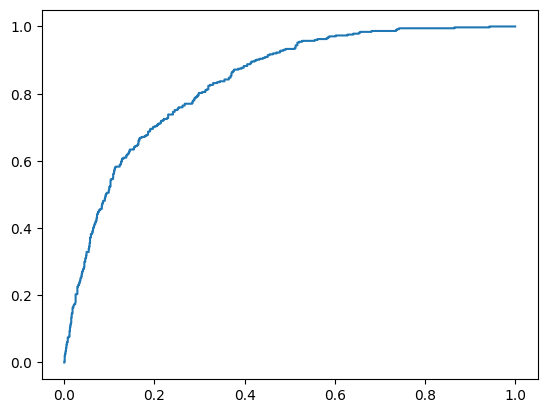

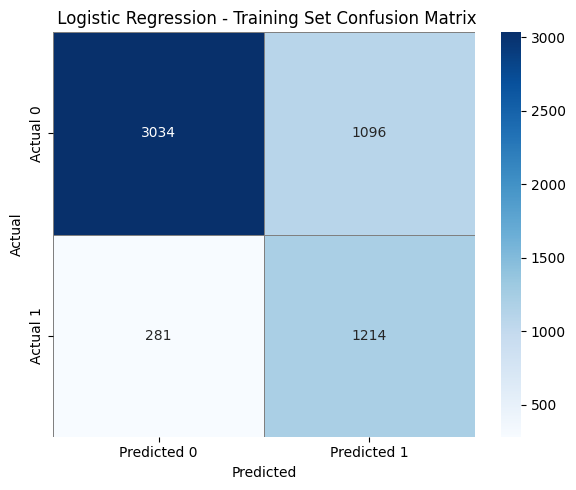

In [100]:
#  Model 1: Logistic Regression
#  Use class_weight='balanced' to automatically handle class imbalance issues
lr = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
auc_lr, lr_model = evaluate_model(lr, X_train, X_test, y_train, y_test, "Logistic Regression")
y_train_pred_lr = lr_model.predict(X_train)
cm_train = confusion_matrix(y_train, y_train_pred_lr)

print("\n=== confusion_matrix ===")
print(confusion_matrix(y_train, y_train_pred_lr))

print("\n=== classification_report ===")
print(classification_report(y_train, y_train_pred_lr, target_names=['Non-churned', 'Churned']))

plt.figure(figsize=(6, 5))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'],
            cbar=True, linewidths=0.5, linecolor='gray')
plt.title(' Logistic Regression - Training Set Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

9. Model 2: Decision(Classification) Tree

Decision Tree AUROC: 0.7777

=== confusion_matrix ===
[[3299  831]
 [ 110 1385]]

=== classification_report ===
              precision    recall  f1-score   support

 Non-churned       0.97      0.80      0.88      4130
     Churned       0.62      0.93      0.75      1495

    accuracy                           0.83      5625
   macro avg       0.80      0.86      0.81      5625
weighted avg       0.88      0.83      0.84      5625



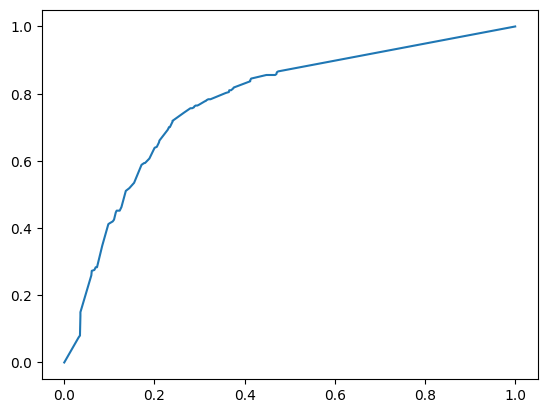

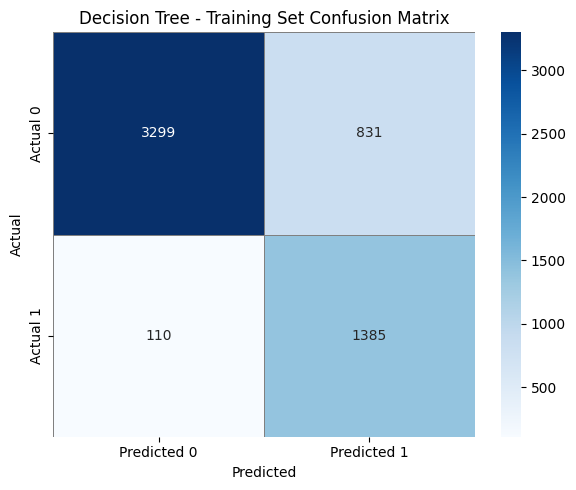

In [101]:
#  Model 2: Decision(Classification) Tree
#  Limit the maximum depth (max_depth=10) to prevent overfitting, and also use class_weight='balanced'
dt = DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=10)
auc_dt, dt_model = evaluate_model(dt, X_train, X_test, y_train, y_test, "Decision Tree")
y_train_pred_dt = dt.predict(X_train)
cm_train_dt = confusion_matrix(y_train, y_train_pred_dt)

print("\n=== confusion_matrix ===")
print(confusion_matrix(y_train, y_train_pred_dt))

print("\n=== classification_report ===")
print(classification_report(y_train, y_train_pred_dt, target_names=['Non-churned', 'Churned']))

plt.figure(figsize=(6, 5))
sns.heatmap(cm_train_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'],
            cbar=True, linewidths=0.5, linecolor='gray')
plt.title('Decision Tree - Training Set Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

10. Model 3: Random Forest

Random Forest AUROC: 0.8361

=== confusion_matrix ===
[[3464  666]
 [ 160 1335]]

=== classification_report ===
              precision    recall  f1-score   support

 Non-churned       0.96      0.84      0.89      4130
     Churned       0.67      0.89      0.76      1495

    accuracy                           0.85      5625
   macro avg       0.81      0.87      0.83      5625
weighted avg       0.88      0.85      0.86      5625



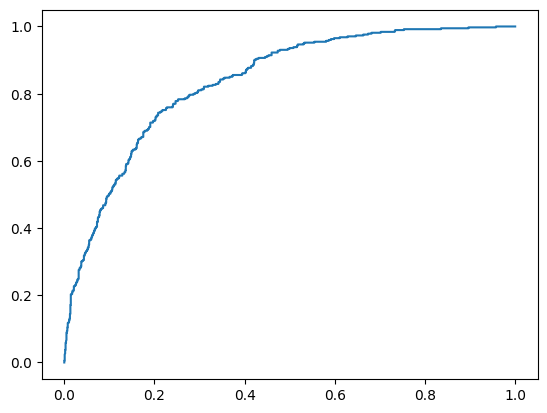

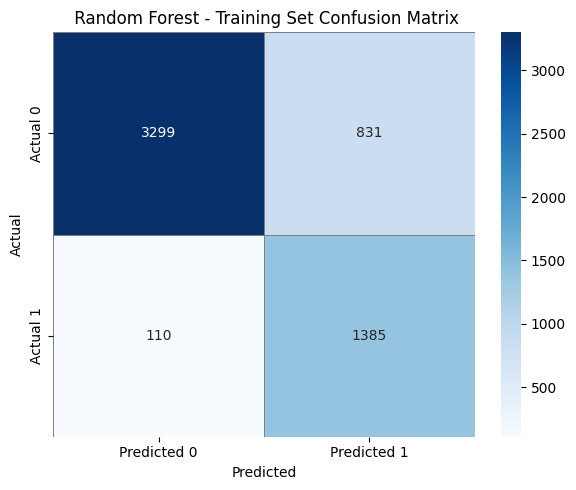

In [102]:
#  Model 3: Random Forest
#  Use 100 trees, limit depth and balance categories
rf = RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=100, max_depth=10)
auc_rf, rf_model = evaluate_model(rf, X_train, X_test, y_train, y_test, "Random Forest")
y_train_pred_rf = rf.predict(X_train)
cm_train_rf = confusion_matrix(y_train, y_train_pred_rf)

print("\n=== confusion_matrix ===")
print(confusion_matrix(y_train, y_train_pred_rf))

print("\n=== classification_report ===")
print(classification_report(y_train, y_train_pred_rf, target_names=['Non-churned', 'Churned']))

cm_train_rf = confusion_matrix(y_train, y_train_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_train_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'],
            cbar=True, linewidths=0.5, linecolor='gray')
plt.title(' Random Forest - Training Set Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

11. Plot complete ROC curve comparison graph （first time）

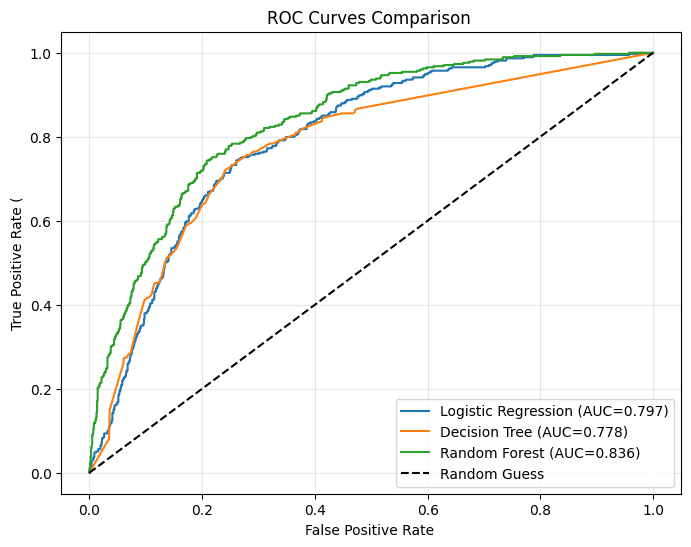


=== Model Performance Summary ===
Logistic Regression AUC: 0.7965
Classification Tree AUC: 0.7777
Random Forest AUC: 0.8361


In [103]:
#  First ROC curve comparison
plt.figure(figsize=(8,6))

#  ROC curve of logistic regression
y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
auc_lr = roc_auc_score(y_test, y_proba_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={auc_lr:.3f})')

#  ROC curve of decision tree
y_proba_dt = dt.predict_proba(X_test)[:, 1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)
auc_dt = roc_auc_score(y_test, y_proba_dt)
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC={auc_dt:.3f})')

#  ROC curve of random forest
y_proba_rf = rf.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
auc_rf = roc_auc_score(y_test, y_proba_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={auc_rf:.3f})')

#  Add random guess baseline (diagonal line
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate ')
plt.ylabel('True Positive Rate (')
plt.title('ROC Curves Comparison ')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

#  Output summary of AUC values for each model
print("\n=== Model Performance Summary ===")
print(f"Logistic Regression AUC: {auc_lr:.4f}")
print(f"Classification Tree AUC: {auc_dt:.4f}")
print(f"Random Forest AUC: {auc_rf:.4f}")

12. Hyperparameter Tuning（For three models）
Tuning can improve model performance, avoid overfitting and accelerate training speed. Hyperparameter tuning is conducted separately for each model to ensure fair potential comparison. Only after optimization can AUC comparison truly reflect the pros and cons of different models.

12-1. Logistic Regression Tuning

In [105]:
#  1. Logistic Regression Tuning
print("="*42)
print("Tuning logistic regression...")
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],           #  Inverse of regularization strength
    'penalty': ['l2']                   #  L2 regularization is commonly used in logistic regression
}
#  Adopt GridSearchCV with roc_auc as scoring metric and 5-fold cross validation
grid_lr = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    param_grid_lr,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
grid_lr.fit(X_train_scaled, y_train)
print("Optimal parameters for Logistic Regression:", grid_lr.best_params_)
print("Optimal cross-validation AUC of Logistic Regression: {:.4f}".format(grid_lr.best_score_))
best_lr = grid_lr.best_estimator_

Tuning logistic regression...
Optimal parameters for Logistic Regression: {'C': 10, 'penalty': 'l2'}
Optimal cross-validation AUC of Logistic Regression: 0.8458


12-2. Decision(Classification) Tree Tuning

In [106]:
#  2. Decision(Classification) Tree Tuning
print("\n" + "="*42)
print("Tuning the Decision(Classification) tree...")
param_grid_dt = {
    'max_depth': [3, 5, 10, None],          #  Maximum depth of the tree
    'min_samples_split': [2, 5, 10],        #  Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4]           #  Minimum number of samples per leaf node
}
grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    param_grid_dt,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
grid_dt.fit(X_train, y_train)
print("Optimal parameters of Decision tree:", grid_dt.best_params_)
print("Optimal cross-validation AUC of Decision tree: {:.4f}".format(grid_dt.best_score_))
best_dt = grid_dt.best_estimator_


Tuning the Decision(Classification) tree...
Optimal parameters of Decision tree: {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}
Optimal cross-validation AUC of Decision tree: 0.8304


12-3. Random Forest Tuning

In [107]:
#  3. Random Forest Tuning
print("\n" + "="*42)
print("Tuning the Random Forest...")
param_grid = {
    'n_estimators': [100, 150],          #  Number of trees
    'max_depth': [6, 8, 10],             #  Maximum depth
    'min_samples_split': [10, 15],       #  Increase samples required for splitting
    'min_samples_leaf': [4, 6],          #  Increase the minimum number of samples required for leaf nodes
    'min_samples_split': [2, 5]          #  Minimum number of samples required for splitting an internal node
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid,
    cv=5,                #  5-fold cross validation
    scoring='roc_auc',   #  Optimization target is AUC
    n_jobs=-1            #  Use all CPU cores
)
grid_rf.fit(X_train, y_train)
print("Optimal parameter combination:", grid_rf.best_params_)
print("Optimal cross-validation AUC: {:.4f}".format(grid_rf.best_score_))
best_rf = grid_rf.best_estimator_


Tuning the Random Forest...
Optimal parameter combination: {'max_depth': 8, 'min_samples_leaf': 6, 'min_samples_split': 2, 'n_estimators': 150}
Optimal cross-validation AUC: 0.8474


13. Plot complete ROC curve comparison graph （second time）
Hyperparameter tuning can boost each model's AUC. It adjusts model performance. Fair comparison and selection of the optimal model can only be achieved after tuning.


Evaluate the tuned model on the test set...


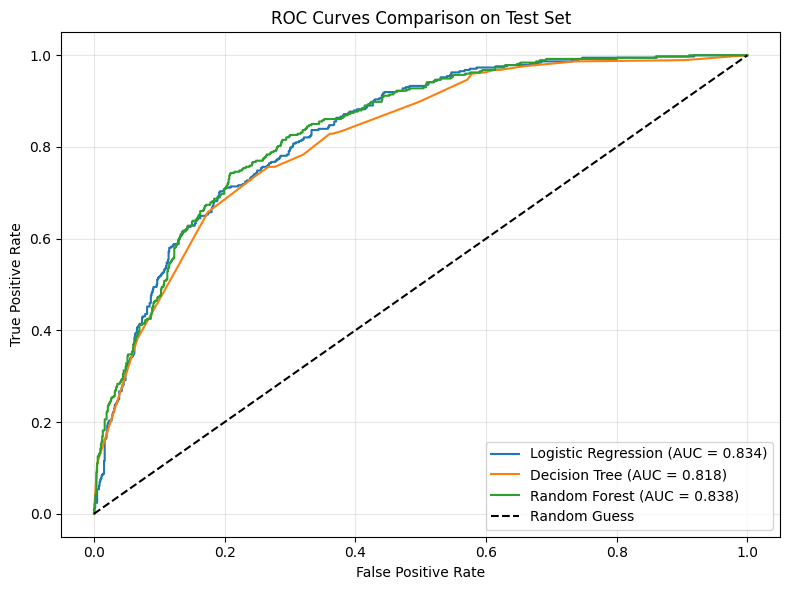

In [108]:
auc_scores = {}

print("\n" + "="*42)
print("Evaluate the tuned model on the test set...")
plt.figure(figsize=(8, 6))

#  Logistic Regression (standardized test set required)
y_proba_lr = best_lr.predict_proba(X_test_scaled)[:, 1]
auc_lr = roc_auc_score(y_test, y_proba_lr)
auc_scores['Logistic Regression'] = auc_lr
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.3f})')

#  Decision(Classification) Tree
y_proba_dt = best_dt.predict_proba(X_test)[:, 1]
auc_dt = roc_auc_score(y_test, y_proba_dt)
auc_scores['Decision Tree'] = auc_dt
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.3f})')

#  Random Forest
y_proba_rf = best_rf.predict_proba(X_test)[:, 1]
auc_rf = roc_auc_score(y_test, y_proba_rf)
auc_scores['Random Forest'] = auc_rf
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})')

#  Draw diagonal line (random guess)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison on Test Set')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

14. Select the optimal model


=== Test set AUC comparison ===
Logistic Regression: 0.8343
Decision Tree: 0.8182
Random Forest: 0.8384

best model is: Random Forest, Test set AUC = 0.8384


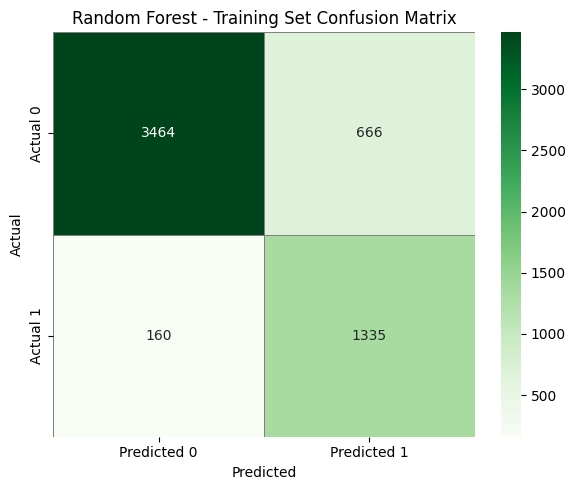

In [109]:
#  Select the optimal model
models = {
    'Logistic Regression': best_lr,
    'Decision Tree': best_dt,
    'Random Forest': best_rf
}
print("\n=== Test set AUC comparison ===")
for name, auc in auc_scores.items():
    print(f"{name}: {auc:.4f}")

best_name = max(auc_scores, key=auc_scores.get)
best_model = models[best_name]
print(f"\nbest model is: {best_name}, Test set AUC = {auc_scores[best_name]:.4f}")

plt.figure(figsize=(6,5))
sns.heatmap(cm_train_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'],
            cbar=True, linewidths=0.5, linecolor='gray')
plt.title('Random Forest - Training Set Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

Compare accuracy based on the training set and test set

In [110]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
#  Prediction probability（Training set）
y_train_pred = best_rf.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)

#  Prediction probability（Test set）
y_test_pred = best_rf.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Training set accuracy: {train_acc:.4f}")
print(f"Test set accuracy: {test_acc:.4f}")
print(f"Degree of overfitting: {train_acc - test_acc:.4f}")
print("\nTest set confusion matrix:\n", confusion_matrix(y_test, y_test_pred))
print("\nTest set classification report:\n", classification_report(y_test, y_test_pred, target_names=['Non-churn', 'Churn']))

Training set accuracy: 0.7936
Test set accuracy: 0.7477
Degree of overfitting: 0.0459

Test set confusion matrix:
 [[760 273]
 [ 82 292]]

Test set classification report:
               precision    recall  f1-score   support

   Non-churn       0.90      0.74      0.81      1033
       Churn       0.52      0.78      0.62       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.76      1407



16. Feature Importance Analysis

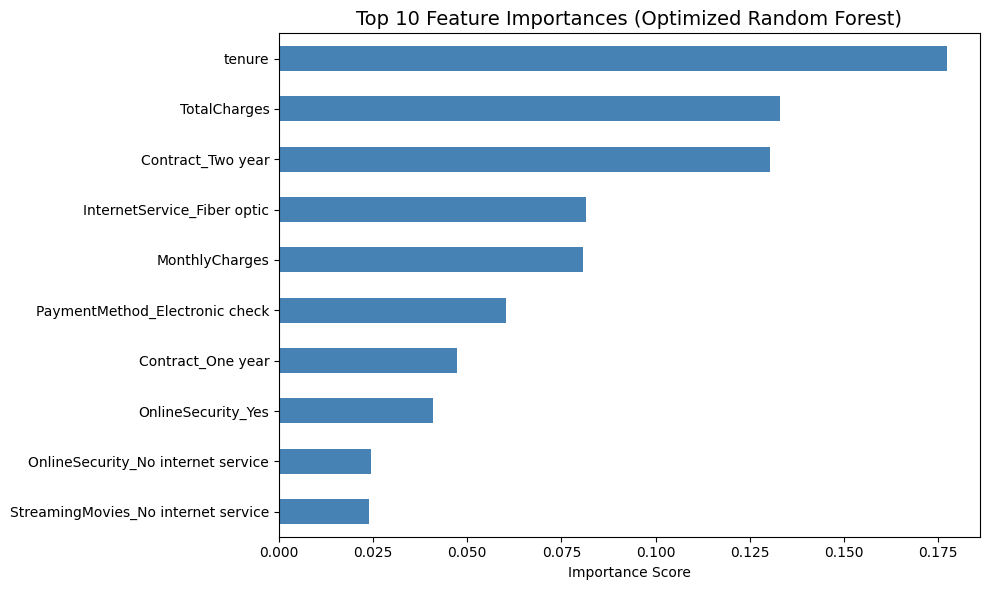

In [111]:
#  output feature importance. A larger coefficient indicates a greater contribution to prediction.
importances = pd.Series(best_rf.feature_importances_, index=X_train.columns)
#  Sort in descending order of importance and select the top 10
top10 = importances.sort_values(ascending=False).head(10)

#  Draw horizontal bar chart
plt.figure(figsize=(10, 6))
top10.plot(kind='barh', color='steelblue')
plt.title('Top 10 Feature Importances (Optimized Random Forest)', fontsize=14)
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()   #  Display the most important features at the top
plt.tight_layout()
plt.show()

Periodic Summary Report

Impact Report of Customer Churn Prediction Model on Business
Based on the established random forest customer churn prediction model, which achieves a test set AUC of approximately 0.836, an accuracy rate of 76.5% and a churn user recall rate of 75%, the model can effectively identify customers with high churn risks and bring the following positive impacts on corporate customer management, revenue growth and overall business performance.

1. Customer Management: Shifting from Passive Response to Active Intervention
1.1 Accurately identify high-risk customers
The model calculates the churn probability of each customer, enabling enterprises to classify customers by high, medium and low risk levels. Priority retention measures can be adopted for customers with a predicted probability above 0.7, while unnecessary disturbances to low-risk customers can be reduced.

1.2 Personalized retention strategies
With feature importance analysis covering contract type, monthly fee, online security service usage and other indicators, enterprises can formulate targeted intervention solutions for different churn causes.
- Offer renewal discounts and automatic renewal guidance for customers on short-term contracts.
- Recommend downgraded packages and preferential offers for price-sensitive customers.
- Provide free trials and service guidance for users who rarely use core services to enhance customer loyalty.

1.3 Optimize customer service resource allocation
Customer service staff can prioritize contacting high-risk clients based on prediction results. This approach improves communication efficiency, avoids one-size-fits-all telemarketing and reduces customer dissatisfaction.

2. Revenue Impact: Cut Churn Rate and Boost Customer Lifetime Value
2.1 Reduce revenue losses caused by customer churn
Assuming the average monthly churn rate stands at 2.5%, precise intervention via the model can lower the rate by 20% to 2.0%, retaining thousands of customers monthly. With an average monthly fee of 70 US dollars per user, hundreds of thousands of dollars in monthly revenue losses can be avoided.

2.2 Improve Customer Lifetime Value (CLV)
Retained customers generate steady recurring revenue. Longer service tenure also raises the possibility of additional purchases and cross-selling. Early intervention effectively extends customer lifespan and greatly lifts CLV.

2.3 Enhance marketing return on investment
Traditional extensive marketing campaigns suffer high costs and low conversion rates. The model helps allocate retention budgets such as coupons and loyalty points to high-value customers at high churn risk, cutting Customer Acquisition Cost and improving marketing ROI.

3. Business Performance: Form a Data-driven Decision Loop
3.1 Establish early warning mechanism
Deploy the model into CRM systems and business intelligence dashboards to automatically update customer churn probability on a weekly and monthly basis, supporting dynamic strategy adjustment.

3.2 Evaluate retention campaign effectiveness
Adopt A/B tests to compare churn rates between customers receiving retention measures and those who do not, so as to quantify the practical value of the model.

3.3 Guide product and service optimization
Key churn influencing factors including contract terms, online security services and technical support are reflected in feature importance. Product teams can carry out targeted upgrades to improve customer satisfaction fundamentally.

4. Implementation Recommendations
- **Short term**: Launch pilot programs of personalized coupons and customer follow-up visits among high-risk customers to assess churn reduction effects.
- **Medium term**: Integrate the model into automated marketing platforms to trigger automatic preferential push once customer churn probability exceeds the threshold.
- **Long term**: Retrain the model regularly with updated customer behavior data to sustain prediction precision.

5. Conclusion
This model serves as a low-cost and high-efficiency early warning tool for customer churn. Transforming analytical results into practical management actions helps enterprises substantially reduce churn rate, raise customer lifetime value and streamline marketing expenditure, achieving balanced growth in revenue and customer satisfaction. Small-scale pilot application is recommended immediately, followed by full-scale promotion after effect verification.

IOM-103 Task A2 part AI using Report
Author: Jianbin Hu（2472161）


In this report, I will describe the assistance and usage details of AI (the AI used is DeepSeek) for this task. The project requires using supervised learning models (logistic regression, decision tree, random forest) to predict customer churn and compare model performance. Through multiple rounds of conversations with the AI, it provided end-to-end guidance on data preprocessing, model building, hyperparameter tuning, performance evaluation, and business interpretation.

Before starting the task, lacking a comprehensive understanding of how to structure the project, I first asked the AI: what is the complete workflow for building a customer churn prediction model? This helped me form a holistic view of the project.

Based on the code provided by the AI, I input the dataset and its description, then modified the relevant variable names accordingly to set up a basic framework. This framework mainly consists of four parts:

Import and clean the data, split the dataset.

Build and train the three models.

Compare model AUC and accuracy, select the best-performing model.

Use the best model to make predictions.

During model development, the AI was deeply involved in two major aspects. The first was debugging when errors occurred. While building the models, I used the AI to handle minor errors such as FileNotFoundError and NameError, as well as issues like an abnormal confusion matrix orientation and how to debug when the difference between training and testing accuracy was too large. In this part, the AI greatly reduced the time I spent finding errors and debugging code. Moreover, the AI not only provided code but also explained the underlying principles, which effectively helped me understand the machine learning workflow.

The second aspect was assisting with model optimization and analysis. When the AI gave the basic framework, I noticed a step for hyperparameter tuning (optional). After asking the AI for specific details, I realized that this offers great advantages for adapting to specific applications. Default model parameters might lead to inaccurate predictions, but after tuning the parameters, the accuracy and fit of the model could be significantly improved. Therefore, after consulting the AI on operational details and suggestions, I performed secondary tuning for all three models and compared their AUROC scores, finally selecting the random forest model.

The above covers most of the AI's involvement during model construction. The AI also handled some translation tasks. In summary, the AI significantly lowered the barrier for me to complete machine learning tasks. From data cleaning to model deployment suggestions, the AI provided timely, accurate, and actionable guidance.

